In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import time


In [17]:
N=1000000

a=int(0)
b=np.ones(N,dtype=int)
start_time = time.time()
for j in range(N):
    a+=1
end_time = time.time()
print(end_time - start_time)

start_time = time.time()
print(np.sum(b))
end_time = time.time()
print(end_time - start_time)

0.040935516357421875
1000000
0.0004951953887939453


In [ ]:

# x from -10 to 10
x_values = np.arange(-10, 11)
n_points = len(x_values)
known_indices = [5, 10, 15]  # x = -5, 0, +5

# Generate (a, b, c) quadratic data: y = ax² + bx + c
def generate_quadratics(n_samples):
    X_input = []  # samples at -5, 0, +5
    Y_full = []   # full function values from -10 to +10
    for _ in range(n_samples):
        a, b, c = np.random.uniform(-1, 1, 3)
        y = a * x_values**2 + b * x_values + c
        X_input.append(y[known_indices])
        Y_full.append(y)
    return np.array(X_input, dtype=np.float32), np.array(Y_full, dtype=np.float32)

# Datasets
X_train, Y_train = generate_quadratics(1000)
X_test, Y_test = generate_quadratics(100)

# Tensors
X_train_tensor = torch.tensor(X_train)
Y_train_tensor = torch.tensor(Y_train)
X_test_tensor = torch.tensor(X_test)
Y_test_tensor = torch.tensor(Y_test)


In [39]:
def create_local_mask(out_features, in_features, window_size, wrap=True):
    mask = torch.zeros(out_features, in_features)
    half_window = window_size // 2
    for i in range(out_features):
        for j in range(-half_window, half_window + 1):
            idx = (i + j) % in_features if wrap else min(max(i + j, 0), in_features - 1)
            mask[i, idx] = 1.0
    return mask


class SparseLinear(nn.Module):
    def __init__(self, in_features, out_features, mask):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.1)
        self.bias = nn.Parameter(torch.zeros(out_features))
        self.register_buffer("mask", mask)

    def forward(self, x):
        return torch.nn.functional.linear(x, self.weight * self.mask, self.bias)

Epoch 0, Loss: 816.0386
Epoch 20, Loss: 812.7150
Epoch 40, Loss: 805.8315
Epoch 60, Loss: 790.5464
Epoch 80, Loss: 760.0313
Epoch 100, Loss: 707.4126
Epoch 120, Loss: 629.3547
Epoch 140, Loss: 529.8167
Epoch 160, Loss: 420.7427
Epoch 180, Loss: 316.9108
Epoch 200, Loss: 229.4951
Epoch 220, Loss: 162.8375
Epoch 240, Loss: 115.6057
Epoch 260, Loss: 83.3835
Epoch 280, Loss: 61.4598
Epoch 300, Loss: 46.4372
Epoch 320, Loss: 36.1330
Epoch 340, Loss: 29.0673
Epoch 360, Loss: 24.2113
Epoch 380, Loss: 20.8691
Epoch 400, Loss: 18.5773
Epoch 420, Loss: 17.0208
Epoch 440, Loss: 15.9763
Epoch 460, Loss: 15.2810
Epoch 480, Loss: 14.8162
Epoch 500, Loss: 14.4978
Epoch 520, Loss: 14.2685
Epoch 540, Loss: 14.0911
Epoch 560, Loss: 13.9427
Epoch 580, Loss: 13.8095
Epoch 600, Loss: 13.6839
Epoch 620, Loss: 13.5615
Epoch 640, Loss: 13.4400
Epoch 660, Loss: 13.3182
Epoch 680, Loss: 13.1955
Epoch 700, Loss: 13.0715
Epoch 720, Loss: 12.9460
Epoch 740, Loss: 12.8189
Epoch 760, Loss: 12.6900
Epoch 780, Loss: 1

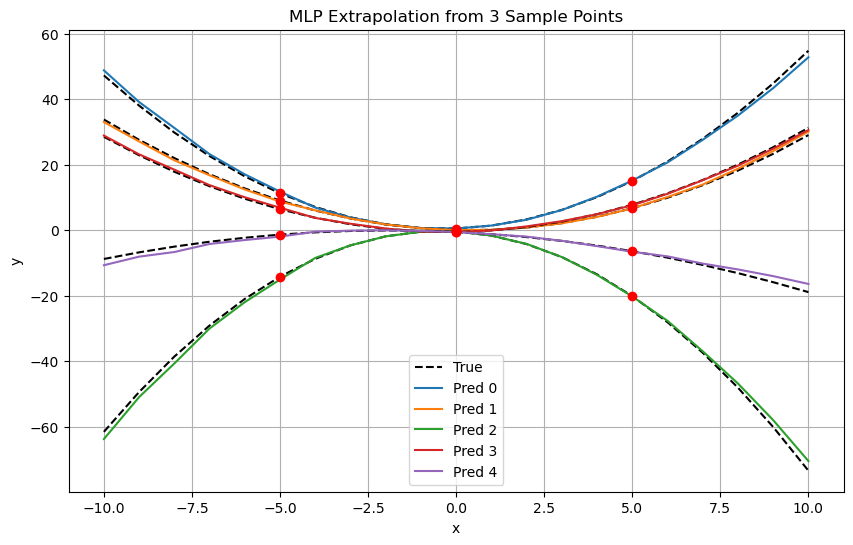

In [46]:

# MLP: 3 input → 64 → 64 → 21 output
class LocalSparseMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = SparseLinear(
            3, 10, create_local_mask(10, 3, window_size=3, wrap=True)
        )
        self.layer2 = SparseLinear(
            10, 21, create_local_mask(21, 10, window_size=5, wrap=True)
        )
        self.layer3 = SparseLinear(
            21, 21, create_local_mask(21, 21, window_size=5, wrap=False)
        )
        self.relu = nn.ReLU()

    def forward(self, x):
        #x = self.relu(self.layer1(x))
        #x = self.relu(self.layer2(x))
       # x = self.layer3(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        return x

# Train
model = LocalSparseMLP()
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

for epoch in range(2000):
    model.train()
    optimizer.zero_grad()
    output = model(X_train_tensor)
    loss = loss_fn(output, Y_train_tensor)
    loss.backward()
    optimizer.step()
    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

# Evaluate
model.eval()
with torch.no_grad():
    Y_pred = model(X_test_tensor)

# Plot a few examples
plt.figure(figsize=(10, 6))
for i in range(5):
    plt.plot(x_values, Y_test[i], 'k--', label="True" if i == 0 else "")
    plt.plot(x_values, Y_pred[i].numpy(), label=f"Pred {i}")
    plt.scatter(x_values[known_indices], X_test[i], c='red', zorder=5)
plt.title("MLP Extrapolation from 3 Sample Points")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.legend()
plt.show()



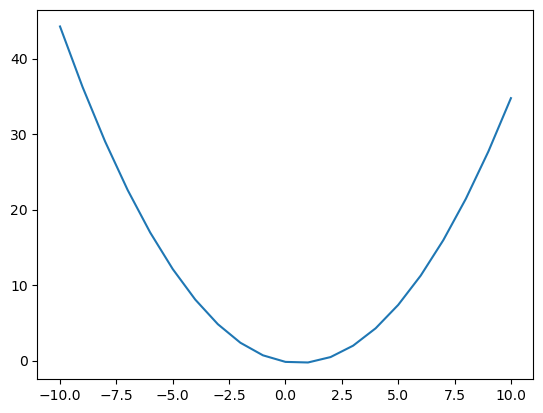

In [47]:
random_quadratic_function=generate_quadratics(1)

plt.plot(x_values, random_quadratic_function[1].flatten())
plt.show()



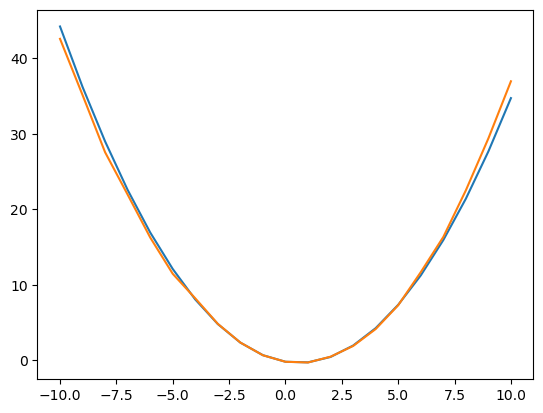

In [48]:
extrapolated_function=model(torch.tensor(random_quadratic_function[0]))

plt.plot(x_values, random_quadratic_function[1].flatten())
plt.plot(x_values, extrapolated_function.detach().numpy().flatten())
plt.show()

In [51]:
model.layer1.weight

Parameter containing:
tensor([[ 0.6175, -0.6176,  0.2980],
        [ 0.4278, -0.8099,  0.3735],
        [-0.4952,  0.9293, -0.2907],
        [ 0.8069, -0.3269, -0.1322],
        [ 0.3073,  0.6024,  0.3068],
        [ 0.0855,  0.8873,  0.4353],
        [ 0.1027, -0.6474,  0.6198],
        [ 0.0071,  0.8910, -0.7847],
        [-0.1846,  0.7936, -0.6314],
        [ 0.4319,  0.1030,  0.4178]], requires_grad=True)

In [54]:
create_local_mask(21, 10, window_size=5, wrap=True)

tensor([[1., 1., 1., 0., 0., 0., 0., 0., 1., 1.],
        [1., 1., 1., 1., 0., 0., 0., 0., 0., 1.],
        [1., 1., 1., 1., 1., 0., 0., 0., 0., 0.],
        [0., 1., 1., 1., 1., 1., 0., 0., 0., 0.],
        [0., 0., 1., 1., 1., 1., 1., 0., 0., 0.],
        [0., 0., 0., 1., 1., 1., 1., 1., 0., 0.],
        [0., 0., 0., 0., 1., 1., 1., 1., 1., 0.],
        [0., 0., 0., 0., 0., 1., 1., 1., 1., 1.],
        [1., 0., 0., 0., 0., 0., 1., 1., 1., 1.],
        [1., 1., 0., 0., 0., 0., 0., 1., 1., 1.],
        [1., 1., 1., 0., 0., 0., 0., 0., 1., 1.],
        [1., 1., 1., 1., 0., 0., 0., 0., 0., 1.],
        [1., 1., 1., 1., 1., 0., 0., 0., 0., 0.],
        [0., 1., 1., 1., 1., 1., 0., 0., 0., 0.],
        [0., 0., 1., 1., 1., 1., 1., 0., 0., 0.],
        [0., 0., 0., 1., 1., 1., 1., 1., 0., 0.],
        [0., 0., 0., 0., 1., 1., 1., 1., 1., 0.],
        [0., 0., 0., 0., 0., 1., 1., 1., 1., 1.],
        [1., 0., 0., 0., 0., 0., 1., 1., 1., 1.],
        [1., 1., 0., 0., 0., 0., 0., 1., 1., 1.],


In [55]:
create_local_mask(10, 3, window_size=3, wrap=True)

tensor([[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]])